Importing Libraries

In [9]:
import numpy as np
import math
import matplotlib.pyplot as plt

Defining Parameters

In [3]:
maxiter = 50
eps = 1.0e-5

## **Question 1:**

(12 points)

Use bisection, Secant and Newton-Raphson to solve the equation 3x = tan(x). Plot the
function in the range (0.0, 1.57).

(a) Define a function to call the method, such as, bisection(f,L,R,eps,maxiter), where f is the
function whose root is within bracketing interval L and R.

(b) For bisection, the function should check if the bracketing interval is propper.

(c) The function should check if the given input points are roots.

(d) The function should return the required number of iterations and the root.

(e) For bisection, starting interval could be [1.2,1.4].

(f) For Secant the first two points could be [1.2,1.25].

(g) For Newton-Raphson, the starting point is 1.2.

Defining Function

In [66]:
def f(x):
  return 3*x - math.tan(x)

**Bisection Method**

In [147]:
def bisection(f, left: float, right: float, eps: float, maxiter: int = 100):

  # Bad Interval
  if f(left)*f(right) > 0:
    print("Bad Interval")
    return None

  # If the roots are at the interval ends
  if abs(f(left)) < eps:
    return (left, 0)
  if abs(f(right)) < eps:
    return (right, 0)

  mid = (left + right)/2
  iter = 0

  # Loops runs until the function value is within threshold or maxiterations are not reached
  while abs(f(mid)) > eps and iter < maxiter:
    iter += 1
    # print(iter, f(mid))     # To print iteration and function value after each iteration

    if f(left)*f(mid) < 0:    # Root in between left and mid
      right = mid
    else:                     # Root in between mid and right
      left = mid

    mid = (left + right)/2

  # If maximum number of iterations are reached and root is not found
  if iter == maxiter and abs(f(mid)) > eps:
    print("Did not converge")
    return None

  # Else return root
  return (mid, iter)

Implementing Bisection

In [149]:
left = 1.2
right = 1.4

root, iterations = bisection(f, left, right, eps, maxiter)
# print()
print("Root: ", root)
print("Iterations: ", iterations)

Root:  1.3241943359375
Iterations:  12


**Secant Method**

In [152]:
def secant(f, x1: float, x2: float, eps: float, maxiter: int):

  # Calculating intersection point
  x3 = x2 - (f(x2)*(x2-x1)/(f(x2) - f(x1)))
  iter = 0

  # Loops runs until the function value is within threshold or maxiterations are not reached
  while abs(f(x3)) > eps and iter < maxiter:
    iter += 1
    # print(iter, f(x3))

    # Updating variables
    x1, x2 = x2, x3
    x3 = x2 - (f(x2)*(x2-x1)/(f(x2) - f(x1)))

  return (x3, iter)

Implementing Secant

In [153]:
x1 = 1.2
x2 = 1.25

root, iterations = secant(f, x1, x2, eps, maxiter)
# print()
print("Root: ", root)
print("Iterations: ", iterations)

Root:  1.3241944213969474
Iterations:  5


**Newton-Raphson**

In [154]:
def newton_raphson(f, df, x1: float, eps: float, maxiter: int):

  # Calculating intersection point
  x2 = x1 - f(x1)/df(x1)
  iter = 0

  # Loops runs until the function value is within threshold or maxiterations are not reached
  while abs(f(x2)) > eps and iter < maxiter:
    iter += 1
    # print(iter, f(x2))

    # Updating variables
    x1 = x2
    x2 = x1 - f(x1)/df(x1)

  return (x2, iter)

Derivative of f(x)

In [155]:
def df(x):
  return 3 - (1/math.cos(x))**2

Implementing Newton_Raphson

In [156]:
x1 = 1.2
root, iterations = newton_raphson(f, df, x1, eps, maxiter)
# print()
print("Root: ", root)
print("Iterations: ", iterations)

Root:  1.3241948934722485
Iterations:  4


**Plotting f(x)**

Using numpy in f(x) for plotting

In [78]:
def np_f(x):
  return 3*x - np.tan(x)

Plotting

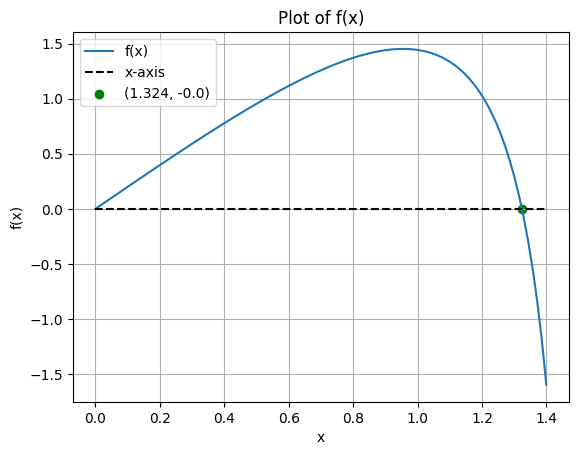

In [96]:
numOfpts = 100
start = 0
end = 1.4

x = np.linspace(0, 1.4, 100)
plt.plot(x, np_f(x), label = "f(x)")
plt.plot(x, np.zeros(100), linestyle="--", color = "black", label = "x-axis")
plt.scatter(root, f(root), color="green", marker="o", label = f"({round(root, 3)}, {round(f(root), 3)})")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Plot of f(x)")

plt.grid()
plt.legend()
plt.show()

## **Question 2:**
(8 points)

Consider a particle moving in an asymmetric one-dimensional double-well potential V (x) =
x^4 + (2x/3)^3 − x^2 eV with a total energy −0.125 eV.

You need to find the turning points for the particle
when it is in either potential well. Plot the function in the range (−1.25, 1.25).

(a) (4 points) Use Bisection method.

(b) (4 points) Use Secant method.

Defining V(x)

In [108]:
def V(x):
  return x**4 + (2*x/3)**3 - x**2 + 0.125

Plotting V(x)

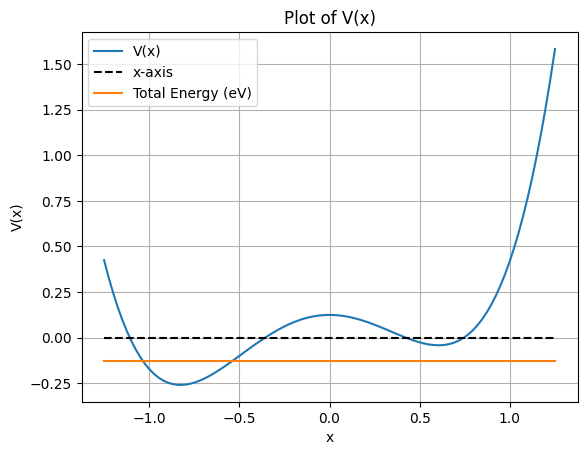

In [109]:
start = -1.25
end = 1.25
numOfpts = 100
E_tot = -0.125

x = np.linspace(start, end, numOfpts)

plt.plot(x, V(x), label = "V(x)")
plt.plot(x, np.zeros(numOfpts), linestyle="--", color = "black", label = "x-axis")
plt.plot(x, np.repeat(E_tot, numOfpts), label = "Total Energy (eV)")

plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("Plot of V(x)")

plt.grid()
plt.legend()
plt.show()

Storing all roots and iterations

In [137]:
roots_bisect = []
iter_bisect = []

roots_secant = []
iter_secant = []

### **Negative Well**

**Bisection Method**

Root 1

In [157]:
left = -1.25
right = -1

root, iterations = bisection(V, left, right, eps, maxiter)

# Ensuring that list does not store extra values if cells are not run in order
if len(roots_bisect) != 0:
  roots_bisect = []
if len(iter_bisect) != 0:
  iter_bisect = []

roots_bisect.append(root)
iter_bisect.append(iterations)

print()
print("Root: ", root)
print("Iterations: ", iterations)


Root:  -1.1073150634765625
Iterations:  13


Root 2

In [158]:
left = -0.5
right = -0.25

root, iterations = bisection(V, left, right, eps, maxiter)

while len(roots_bisect) > 1:
  roots_bisect.pop()
while len(iter_bisect) > 1:
  iter_bisect.pop()

roots_bisect.append(root)
iter_bisect.append(iterations)

print()
print("Root: ", root)
print("Iterations: ", iterations)


Root:  -0.35748291015625
Iterations:  11


**Secant Method**

Root 1

In [159]:
x1 = -1.25
x2 = -1

root, iterations = secant(V, x1, x2, eps, maxiter)

if len(roots_secant) != 0:
  roots_secant = []
if len(iter_secant) != 0:
  iter_secant = []

roots_secant.append(root)
iter_secant.append(iterations)

print()
print("Root: ", root)
print("Iterations: ", iterations)


Root:  -1.1073159349702326
Iterations:  4


Root 2

In [160]:
x1 = -0.5
x2 = -0.25

root, iterations = secant(V, x1, x2, eps, maxiter)

while len(roots_secant) > 1:
  roots_secant.pop()
while len(iter_secant) > 1:
  iter_secant.pop()

roots_secant.append(root)
iter_secant.append(iterations)

print()
print("Root: ", root)
print("Iterations: ", iterations)


Root:  -0.3574693386604535
Iterations:  2


### **Positive Well**

**Bisection Method**

Root 1

In [161]:
left = 0.25
right = 0.5

root, iterations = bisection(V, left, right, eps, maxiter)

while len(roots_bisect) > 2:
  roots_bisect.pop()
while len(iter_bisect) > 2:
  iter_bisect.pop()

roots_bisect.append(root)
iter_bisect.append(iterations)

print()
print("Root: ", root)
print("Iterations: ", iterations)


Root:  0.42431640625
Iterations:  8


Root 2

In [162]:
left = 0.6
right = 0.8

root, iterations = bisection(V, left, right, eps, maxiter)

while len(roots_bisect) > 3:
  roots_bisect.pop()
while len(iter_bisect) > 3:
  iter_bisect.pop()

roots_bisect.append(root)
iter_bisect.append(iterations)

print()
print("Root: ", root)
print("Iterations: ", iterations)


Root:  0.7441650390625
Iterations:  12


**Secant Method**

Root 1

In [163]:
x1 = 0.25
x2 = 0.5

root, iterations = secant(V, x1, x2, eps, maxiter)

while len(roots_secant) > 2:
  roots_secant.pop()
while len(iter_secant) > 2:
  iter_secant.pop()

roots_secant.append(root)
iter_secant.append(iterations)

print()
print("Root: ", root)
print("Iterations: ", iterations)


Root:  0.42435273790751654
Iterations:  2


Root 2

In [164]:
x1 = 0.6
x2 = 0.8

root, iterations = secant(V, x1, x2, eps, maxiter)

while len(roots_secant) > 3:
  roots_secant.pop()
while len(iter_secant) > 3:
  iter_secant.pop()

roots_secant.append(root)
iter_secant.append(iterations)

print()
print("Root: ", root)
print("Iterations: ", iterations)


Root:  0.7441653573101272
Iterations:  4


In [165]:
print("Roots from bisection: ", roots_bisect)
print("Roots from secant: ", roots_secant)

Roots from bisection:  [-1.1073150634765625, -0.35748291015625, 0.42431640625, 0.7441650390625]
Roots from secant:  [-1.1073159349702326, -0.3574693386604535, 0.42435273790751654, 0.7441653573101272]
